In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage
import glob
import cv2
from tqdm import tqdm
import torch

In [5]:
#Used to quickly display an image
def imshow(img, title, cmap = 'gray', axis = 'off', figsize = (10, 10)):
    plt.figure(figsize= figsize)
    plt.imshow(img, cmap = cmap)
    plt.title(title)
    plt.axis(axis)
    plt.show()  

In [7]:
#Storing all file paths of images in a list of strings
import os
directory = r"C:\Users\adamain\Downloads\ProcessedSpiderWebs"
image_paths = []
for filename in os.listdir(directory):
    if filename.lower().endswith(".png"):
        image_paths.append(os.path.join(directory, filename))
print(image_paths)

['C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 4_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26

In [8]:
all_images = []
for path in image_paths:
    all_images.append(cv2.imread(path))
    cv2.cvtColor(all_images[len(all_images)-1], cv2.COLOR_BGR2RGB)

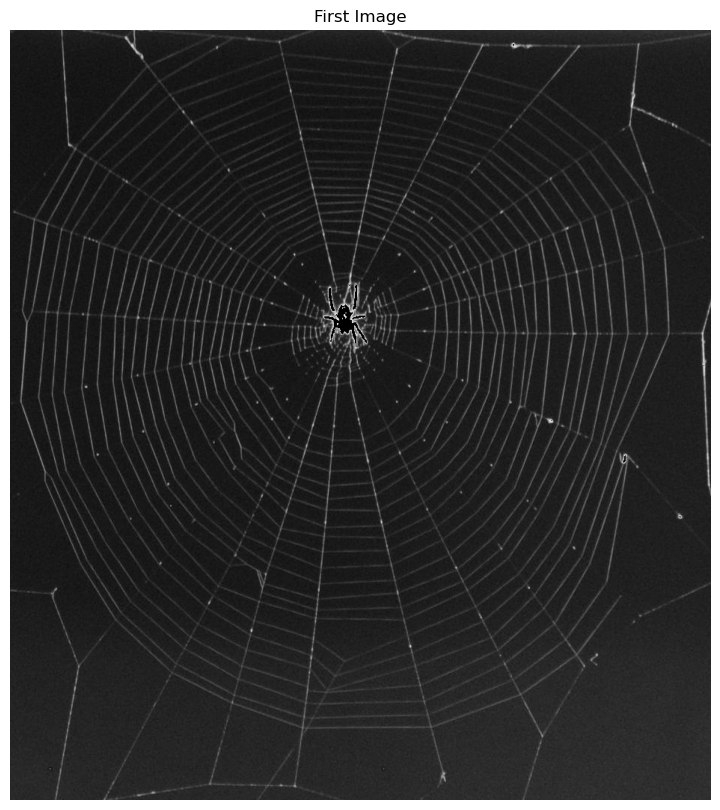

In [9]:
imshow(all_images[0], title = "First Image")

In [203]:
import cv2
import numpy as np

def apply_multi_gabor(gray, orientations=8, ksize=21):
    """
    Apply multiple Gabor filters to enhance line structures in various directions.
    """
    filtered_imgs = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        kernel = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta,
                                    lambd=10.0, gamma=0.5, psi=0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(gray, cv2.CV_8UC1, kernel)
        filtered_imgs.append(filtered)
    return np.max(filtered_imgs, axis=0)

def enhance_spider_web_smart2(gray_image):
    """
    Smarter enhancement: Tophat + multi-orientation Gabor filters + CLAHE.
    Designed to target spider web geometries more robustly.
    """
    gray = gray_image.copy()

    # Step 1: Morphological tophat
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,5))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

    # Step 2: Gabor filters for radial/circular lines
    gabor_enhanced = apply_multi_gabor(tophat, orientations=12, ksize=25)
    imshow(gabor_enhanced, title = "gabor_enhanced")
    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    final = clahe.apply(gabor_enhanced)

    return final


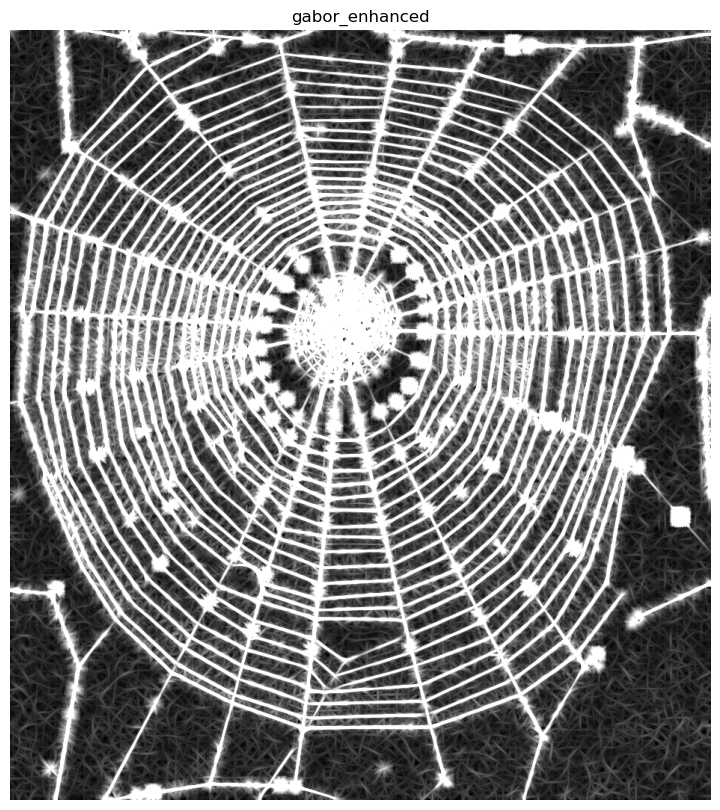

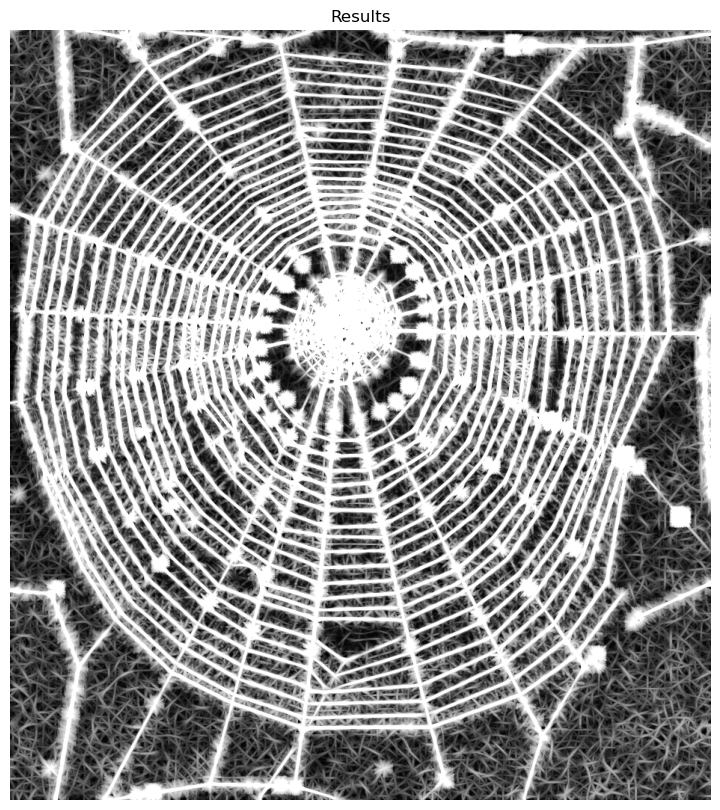

In [204]:
gray = cv2.cvtColor(all_images[0], cv2.COLOR_BGR2GRAY)
results = enhance_spider_web_smart2(gray)
imshow(results, "Results")

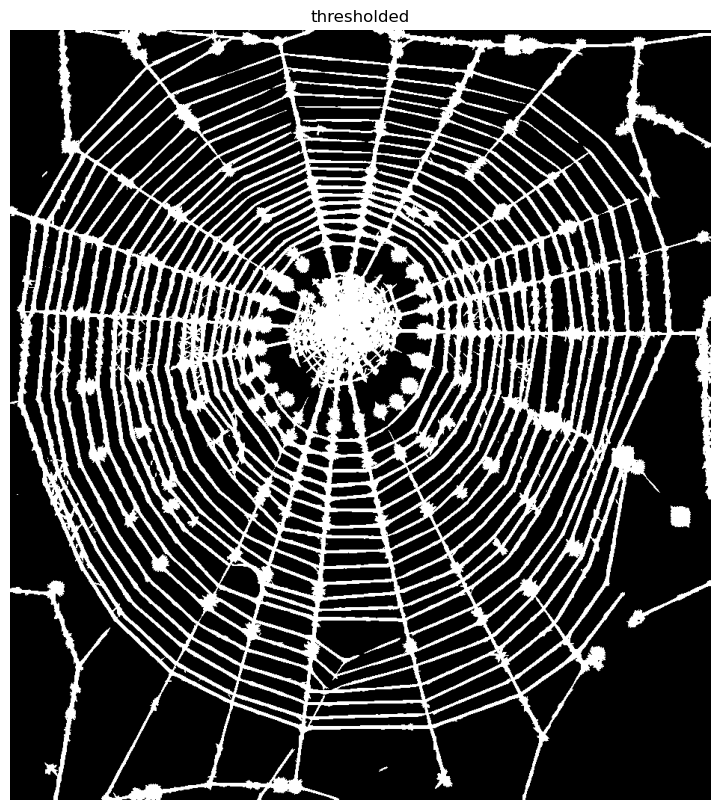

In [205]:
_, edited = cv2.threshold(results, 220, 255, cv2.THRESH_BINARY) 
imshow(edited, title = "thresholded")
#Try using the bright circles to your advantage. We know that they are they because web passes through them, so reconstruct radials passing through bright circles.Then calculate an average radius for the radials and get angle between them (might be easier)

In [228]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import feature

def find_spider_web_center(img, display_result=True):
    """
    Find the center hub of a spider web in an image.
    
    Args:
        image_path (str): Path to the spider web image
        display_result (bool): Whether to display the result with a circle around the center
    
    Returns:
        tuple: (center_x, center_y) coordinates of the web center
    """
    # Apply edge detection
    edges = cv2.Canny(img, 50, 150, apertureSize=3)
    
    # Method 1: Hough Line Transform to find intersection of radial lines
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100)
    
    intersections = []
    
    if lines is not None:
        # Convert lines to cartesian form and find intersections
        for i in range(len(lines)):
            for j in range(i+1, len(lines)):
                rho1, theta1 = lines[i][0]
                rho2, theta2 = lines[j][0]
                
                # Avoid parallel lines
                if abs(theta1 - theta2) < 0.1:
                    continue
                
                # Calculate intersection point
                A = np.array([
                    [np.cos(theta1), np.sin(theta1)],
                    [np.cos(theta2), np.sin(theta2)]
                ])
                b = np.array([rho1, rho2])
                
                try:
                    intersection = np.linalg.solve(A, b)
                    x, y = intersection
                    
                    # Check if intersection is within image bounds
                    if 0 <= x < img.shape[1] and 0 <= y < img.shape[0]:
                        intersections.append((x, y))
                except np.linalg.LinAlgError:
                    continue
    
    # Method 2: Template matching approach - find the densest point of line intersections
    if not intersections:
        # Use contour analysis as fallback
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            # Find the contour closest to the image center
            img_center = (img.shape[1]//2, img.shape[0]//2)
            center_distances = []
            
            for contour in contours:
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    dist = np.sqrt((cx - img_center[0])**2 + (cy - img_center[1])**2)
                    center_distances.append((dist, (cx, cy)))
            
            if center_distances:
                center_distances.sort()
                web_center = center_distances[0][1]
            else:
                web_center = img_center
        else:
            web_center = (img.shape[1]//2, img.shape[0]//2)
    else:
        # Cluster the intersections to find the most likely center
        intersections = np.array(intersections)
        
        # Use k-means clustering or simply take the median
        if len(intersections) > 1:
            # Remove outliers (points too far from the median)
            median_point = np.median(intersections, axis=0)
            distances = np.linalg.norm(intersections - median_point, axis=1)
            threshold = np.percentile(distances, 75)
            
            filtered_intersections = intersections[distances <= threshold]
            web_center = tuple(np.mean(filtered_intersections, axis=0).astype(int))
        else:
            web_center = tuple(intersections[0].astype(int))
    
    # Method 3: Radial gradient analysis (additional verification)
    # Create a gradient magnitude image
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    # Apply morphological operations to enhance web structure
    kernel = np.ones((3,3), np.uint8)
    enhanced = cv2.morphologyEx(gradient_magnitude.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    
    # Find the point with maximum local connectivity (hub-like structure)
    # This is where multiple lines converge
    structure = np.ones((9,9))  # 9x9 connectivity kernel
    local_maxima = feature.peak_local_maxima(enhanced, min_distance=20, threshold_abs=30)
    
    if len(local_maxima[0]) > 0:
        # Find the local maximum closest to our current estimate
        candidates = list(zip(local_maxima[1], local_maxima[0]))  # (x, y) format
        if candidates:
            distances_to_estimate = [np.sqrt((x - web_center[0])**2 + (y - web_center[1])**2) 
                                   for x, y in candidates]
            best_candidate_idx = np.argmin(distances_to_estimate)
            refined_center = candidates[best_candidate_idx]
            
            # Only use refined center if it's reasonably close to our estimate
            if distances_to_estimate[best_candidate_idx] < 50:
                web_center = refined_center
    
    # Display the result
    if display_result:
        plt.figure(figsize=(12, 6))
        
        # Original image with detected center
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('Spider Web with Detected Center')
        
        # Draw circle around the center
        circle = plt.Circle(web_center, 30, color='red', fill=False, linewidth=3)
        plt.gca().add_patch(circle)
        plt.plot(web_center[0], web_center[1], 'ro', markersize=8)
        plt.axis('off')
        
        # Edge detection result
        plt.subplot(1, 2, 2)
        plt.imshow(edges, cmap='gray')
        plt.title('Edge Detection')
        plt.plot(web_center[0], web_center[1], 'ro', markersize=8)
        circle2 = plt.Circle(web_center, 30, color='red', fill=False, linewidth=2)
        plt.gca().add_patch(circle2)
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return web_center

# Example usage function
def analyze_spider_web(image_path):
    """
    Convenience function to analyze a spider web image.
    
    Args:
        image_path (str): Path to the spider web image
    """
    try:
        center = find_spider_web_center(image_path)
        print(f"Spider web center detected at coordinates: ({center[0]}, {center[1]})")
        return center
    except Exception as e:
        print(f"Error analyzing spider web: {e}")
        return None

# Additional utility function for batch processing
def find_web_centers_batch(image_paths):
    """
    Process multiple spider web images and find their centers.
    
    Args:
        image_paths (list): List of paths to spider web images
    
    Returns:
        dict: Dictionary mapping image paths to their detected centers
    """
    results = {}
    for path in image_paths:
        try:
            center = find_spider_web_center(path, display_result=False)
            results[path] = center
            print(f"{path}: Center at ({center[0]}, {center[1]})")
        except Exception as e:
            print(f"Error processing {path}: {e}")
            results[path] = None
    
    return results

# Example of how to use the function:
if __name__ == "__main__":
    # Analyze the spider web
    center = analyze_spider_web(edited)

Error analyzing spider web: too many values to unpack (expected 2)


In [23]:
import numpy as np
import cv2
from sklearn.cluster import DBSCAN

def find_web_center_intersection(image, hough_threshold=30, eps=20, max_lines=150):
    """
    Estimate web center by intersecting full Hough lines (rho, theta).
    
    Args:
        image: Binary image (values 0 or 1)
        hough_threshold: Threshold for Hough line detection
        eps: DBSCAN eps parameter for clustering intersections
        max_lines: Max number of lines to consider
    
    Returns:
        (cx, cy): Estimated center
    """
    h, w = image.shape
    edges = cv2.Canny(image.astype(np.uint8) * 255, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=hough_threshold)

    if lines is None or len(lines) < 3:
        return w // 2, h // 2  # fallback center

    lines = lines[:max_lines]
    intersections = []

    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            rho1, theta1 = lines[i][0]
            rho2, theta2 = lines[j][0]

            # Skip nearly parallel lines
            if abs(theta1 - theta2) < 0.1 or abs(theta1 - theta2) > np.pi - 0.1:
                continue

            # Solve for intersection
            A = np.array([[np.cos(theta1), np.sin(theta1)],
                          [np.cos(theta2), np.sin(theta2)]])
            b = np.array([rho1, rho2])

            try:
                intersection = np.linalg.solve(A, b)
                x, y = intersection
                if 0 <= x < w and 0 <= y < h:
                    intersections.append([x, y])
            except np.linalg.LinAlgError:
                continue

    if len(intersections) < 3:
        return w // 2, h // 2

    # Cluster intersections to find densest cluster
    intersections = np.array(intersections)
    clustering = DBSCAN(eps=eps, min_samples=2).fit(intersections)
    labels = clustering.labels_

    if np.max(labels) == -1:
        return w // 2, h // 2

    best_cluster = max(set(labels) - {-1}, key=lambda l: np.sum(labels == l))
    cluster_points = intersections[labels == best_cluster]
    cx, cy = np.mean(cluster_points, axis=0)

    return int(cx), int(cy)


In [ ]:
import numpy as np
import cv2
from sklearn.cluster import DBSCAN

def angle_between(v1, v2):
    """Return angle between two vectors in radians."""
    v1 = v1 / (np.linalg.norm(v1) + 1e-6)
    v2 = v2 / (np.linalg.norm(v2) + 1e-6)
    dot = np.clip(np.dot(v1, v2), -1.0, 1.0)
    return np.arccos(dot)

import numpy as np
import cv2
from sklearn.cluster import DBSCAN

def refine_center(image, center_guess, max_lines=200, eps=20):
    """
    Refine web center by selecting lines near a guess and intersecting them.
    
    Args:
        image: Binary image (0 or 1)
        center_guess: Tuple (x, y)
        max_lines: Max number of closest lines to consider
        eps: DBSCAN clustering radius
    
    Returns:
        (cx, cy): Refined center
    """
    h, w = image.shape
    edges = cv2.Canny(image.astype(np.uint8) * 255, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=30)

    if lines is None or len(lines) < 3:
        return center_guess

    # Sort lines by how close they pass to center_guess
    center_guess = np.array(center_guess)
    line_distances = []
    for line in lines:
        rho, theta = line[0]
        # Closest point on the line to the center (from point-line distance formula)
        x0 = rho * np.cos(theta)
        y0 = rho * np.sin(theta)
        dist = np.linalg.norm(np.cross([np.cos(theta), np.sin(theta)], center_guess - np.array([x0, y0])))
        line_distances.append((dist, line))

    # Take the N closest lines
    closest_lines = [line for _, line in sorted(line_distances, key=lambda x: x[0])[:max_lines]]

    intersections = []
    for i in range(len(closest_lines)):
        for j in range(i + 1, len(closest_lines)):
            rho1, theta1 = closest_lines[i][0]
            rho2, theta2 = closest_lines[j][0]

            # Skip nearly parallel lines
            if abs(theta1 - theta2) < 0.1 or abs(theta1 - theta2) > np.pi - 0.1:
                continue

            A = np.array([[np.cos(theta1), np.sin(theta1)],
                          [np.cos(theta2), np.sin(theta2)]])
            b = np.array([rho1, rho2])
            try:
                inter = np.linalg.solve(A, b)
                x, y = inter
                if 0 <= x < w and 0 <= y < h:
                    intersections.append([x, y])
            except np.linalg.LinAlgError:
                continue

    if len(intersections) < 3:
        return center_guess

    intersections = np.array(intersections)
    clustering = DBSCAN(eps=eps, min_samples=3).fit(intersections)
    labels = clustering.labels_

    if np.max(labels) == -1:
        return center_guess

    best_cluster = max(set(labels) - {-1}, key=lambda l: np.sum(labels == l))
    cluster_points = intersections[labels == best_cluster]
    cx, cy = np.mean(cluster_points, axis=0)

    return int(cx), int(cy)



In [82]:
import cv2
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

def estimate_web_center(binary_image,
                        min_line_length=100,
                        hough_threshold=80,
                        eps=10,
                        min_samples=5,
                        debug=False):
    # 1. Detect edges
    edges = cv2.Canny(binary_image, 50, 150)

    # 2. Detect lines using Probabilistic Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=hough_threshold,
                            minLineLength=min_line_length, maxLineGap=10)
    if lines is None:
        print("No lines detected.")
        return None

    # 3. Extend each line far beyond original length
    extended_lines = []
    h, w = binary_image.shape
    for line in lines:
        x1, y1, x2, y2 = line[0]
        vx, vy = x2 - x1, y2 - y1
        if vx == 0 and vy == 0:
            continue
        length = np.hypot(vx, vy)
        vx, vy = vx / length, vy / length
        t = max(h, w)  # extend long enough to reach across image
        x1_ext, y1_ext = int(x1 - vx * t), int(y1 - vy * t)
        x2_ext, y2_ext = int(x1 + vx * t), int(y1 + vy * t)
        extended_lines.append(((x1_ext, y1_ext), (x2_ext, y2_ext)))

    # 4. Compute pairwise intersections
    def compute_intersection(p1, p2, q1, q2):
        def line(p1, p2):
            A = p1[1] - p2[1]
            B = p2[0] - p1[0]
            C = p1[0]*p2[1] - p2[0]*p1[1]
            return A, B, -C
        L1 = line(p1, p2)
        L2 = line(q1, q2)
        D = L1[0]*L2[1] - L1[1]*L2[0]
        if D == 0:
            return None
        x = (L1[2]*L2[1] - L1[1]*L2[2]) / D
        y = (L1[0]*L2[2] - L1[2]*L2[0]) / D
        return int(x), int(y)

    intersections = []
    for i in range(len(extended_lines)):
        for j in range(i + 1, len(extended_lines)):
            p1, p2 = extended_lines[i]
            q1, q2 = extended_lines[j]
            pt = compute_intersection(p1, p2, q1, q2)
            if pt and 0 <= pt[0] < w and 0 <= pt[1] < h:
                intersections.append(pt)

    if len(intersections) == 0:
        print("No intersections found.")
        return None

    # 5. Cluster intersection points to find densest cluster (likely center)
    points = np.array(intersections)
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_

    if np.all(labels == -1):
        print("No dominant intersection cluster found.")
        return None

    # Take the largest cluster
    unique, counts = np.unique(labels[labels != -1], return_counts=True)
    main_cluster_label = unique[np.argmax(counts)]
    main_cluster_points = points[labels == main_cluster_label]
    center = np.mean(main_cluster_points, axis=0).astype(int)

    if debug:
        plt.figure(figsize=(10, 10))
        plt.imshow(binary_image, cmap='gray')
        for (x1, y1), (x2, y2) in extended_lines:
            plt.plot([x1, x2], [y1, y2], 'r-', alpha=0.2)
        plt.scatter(points[:, 0], points[:, 1], s=10, c='cyan', alpha=0.4)
        plt.scatter(*center, c='yellow', s=100, marker='x')
        plt.title('Estimated Web Center')
        plt.axis('off')
        plt.show()

    return tuple(center)



In [86]:
import matplotlib.pyplot as plt

def show_web_and_center(image, center, figsize=(8, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap='gray')
    plt.scatter(*center, c='red', s=100, marker='x', label='Estimated Center')
    plt.title('Spider Web with Estimated Center')
    plt.axis('off')
    plt.legend()
    plt.show()


In [88]:
center = estimate_web_center(edited)

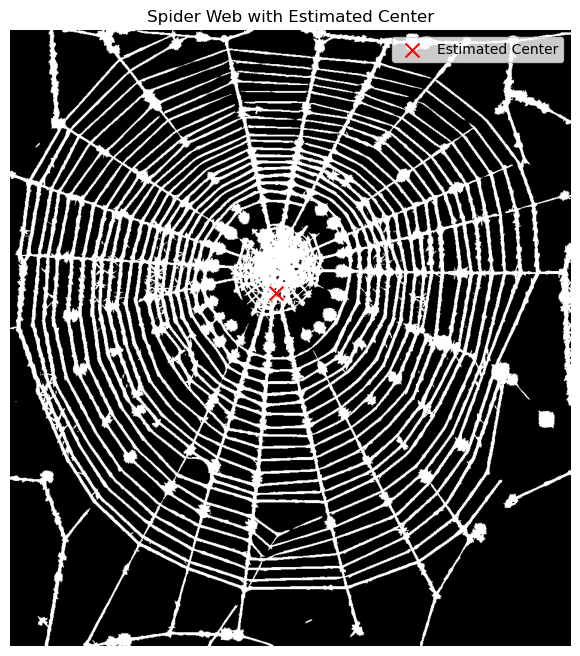

In [89]:
show_web_and_center(edited, center)

In [122]:
def refine_center_via_inner_circle(image, approx_center, crop_size=95, debug=False):
    x, y = approx_center
    h, w = image.shape

    # 1. Crop around the approximate center
    x1, x2 = max(0, x - crop_size), min(w, x + crop_size)
    y1, y2 = max(0, y - crop_size), min(h, y + crop_size)
    cropped = image[y1:y2, x1:x2]
    imshow(cropped, "cropped")

    # 2. Threshold and find contours
    _, thresh = cv2.threshold(cropped, 200, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("No contours found in crop.")
        return approx_center  # fallback

    # 3. Pick the largest contour and compute centroid
    largest = max(contours, key=cv2.contourArea)
    M = cv2.moments(largest)
    if M["m00"] == 0:
        return approx_center

    cx = int(M["m10"] / M["m00"]) + x1
    cy = int(M["m01"] / M["m00"]) + y1

    if debug:
        import matplotlib.pyplot as plt
        debug_img = image.copy()
        cv2.circle(debug_img, (cx, cy), 5, (127), -1)
        plt.figure(figsize=(8, 8))
        plt.imshow(debug_img, cmap='gray')
        plt.scatter(*approx_center, color='red', label='Initial')
        plt.scatter(cx, cy, color='yellow', label='Refined Center')
        plt.legend()
        plt.title("Refined Web Center via Inner Circle")
        plt.axis('off')
        plt.show()

    return (cx, cy)


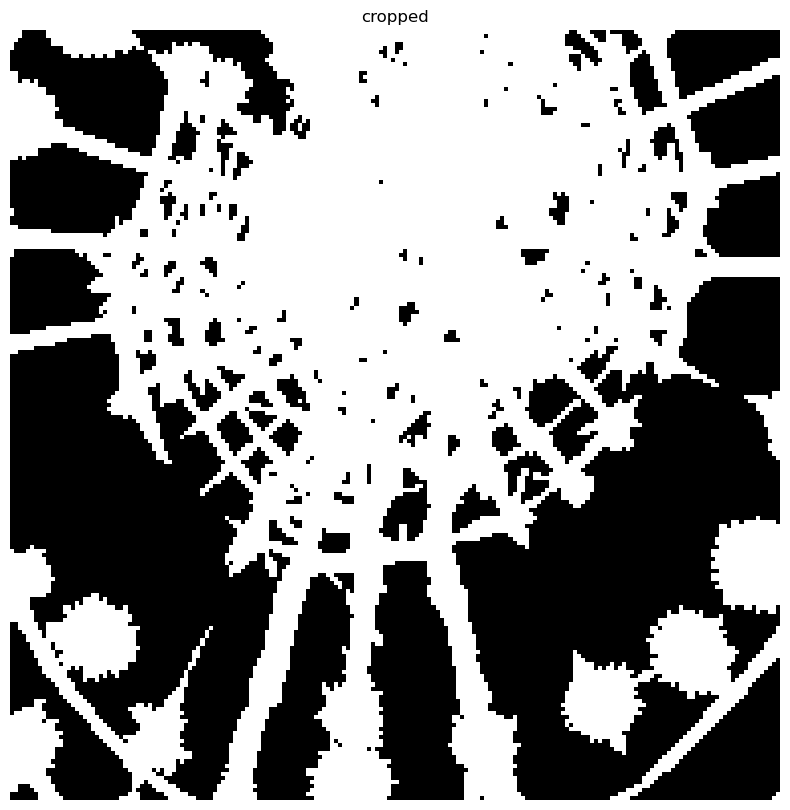

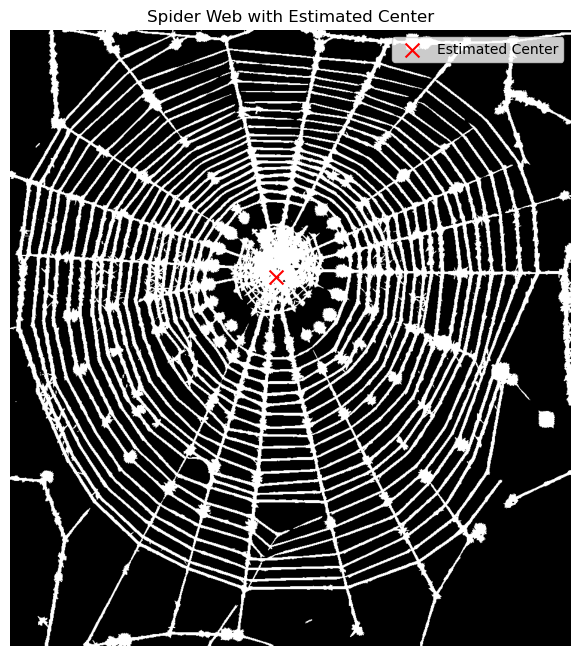

(445, 412)


In [123]:
refined_center = refine_center_via_inner_circle(edited, center)
show_web_and_center(edited, refined_center)
print(refined_center)

In [240]:
import cv2
import numpy as np
from scipy import ndimage
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

def find_hub_ellipse(binary_image, center_coords, hub_search_radius=50, 
                     min_contour_area=100, initial_padding=1.2, 
                     black_pixel_threshold=0.15, max_expansion_factor=3.0, 
                     expansion_step=0.1):
    """
    Find an ellipse that bounds the bright central hub of a spider web.
    Iteratively expands the ellipse until a threshold of black pixels is reached.
    
    Parameters:
    -----------
    binary_image : numpy.ndarray
        Binarized grayscale image of the spider web (0 for background, 255 for web)
    center_coords : tuple
        (x, y) coordinates of the estimated center of the web
    hub_search_radius : int
        Radius around center to search for hub pixels
    min_contour_area : int
        Minimum area for contours to be considered
    initial_padding : float
        Initial factor to expand the ellipse beyond the detected hub region
    black_pixel_threshold : float
        Fraction of black pixels inside ellipse to stop expansion (0.0 to 1.0)
    max_expansion_factor : float
        Maximum expansion factor to prevent infinite growth
    expansion_step : float
        Step size for iterative expansion
    
    Returns:
    --------
    ellipse_params : tuple
        ((center_x, center_y), (width, height), angle) for the bounding ellipse
    hub_mask : numpy.ndarray
        Binary mask of the detected hub region
    """
    
    # Ensure image is binary
    if binary_image.max() > 1:
        binary_image = (binary_image > 0).astype(np.uint8) * 255
    
    center_x, center_y = center_coords
    h, w = binary_image.shape
    
    # Create a circular mask around the estimated center
    y_grid, x_grid = np.ogrid[:h, :w]
    center_mask = (x_grid - center_x)**2 + (y_grid - center_y)**2 <= hub_search_radius**2
    
    # Extract the region around the center
    hub_region = binary_image.copy()
    hub_region[~center_mask] = 0
    
    # Apply morphological operations to clean up the hub region
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    hub_region = cv2.morphologyEx(hub_region, cv2.MORPH_CLOSE, kernel)
    hub_region = cv2.morphologyEx(hub_region, cv2.MORPH_OPEN, kernel)
    
    # Find contours in the hub region
    contours, _ = cv2.findContours(hub_region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("No contours found in hub region")
        return None, None
    
    # Filter contours by area and distance from center
    valid_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < min_contour_area:
            continue
            
        # Check if contour is close to the estimated center
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            dist_from_center = np.sqrt((cx - center_x)**2 + (cy - center_y)**2)
            
            if dist_from_center < hub_search_radius * 0.8:  # Within 80% of search radius
                valid_contours.append(contour)
    
    if not valid_contours:
        print("No valid contours found near center")
        return None, None
    
    # Combine all valid contours
    all_points = np.vstack(valid_contours)
    
    # Create hub mask
    hub_mask = np.zeros_like(binary_image)
    cv2.drawContours(hub_mask, valid_contours, -1, 255, -1)
    
    # Fit ellipse to the combined contour points
    if len(all_points) >= 5:  # Minimum points needed for ellipse fitting
        base_ellipse = cv2.fitEllipse(all_points)
        (center_x_fit, center_y_fit), (base_width, base_height), angle = base_ellipse
        
        # Start with a circle - use the average of width and height
        circle_diameter = (base_width + base_height) / 2
        circle_ellipse = ((center_x_fit, center_y_fit), (circle_diameter, circle_diameter), 0)
        
        # Iteratively expand circle until black pixel threshold is reached
        current_padding = initial_padding
        best_circle = None
        
        while current_padding <= max_expansion_factor:
            # Create current circle with padding
            current_diameter = circle_diameter * current_padding
            current_circle = ((center_x_fit, center_y_fit), (current_diameter, current_diameter), 0)
            
            # Create mask for current circle
            circle_mask = np.zeros_like(binary_image)
            cv2.ellipse(circle_mask, current_circle, 255, -1)
            
            # Calculate fraction of black pixels inside circle
            pixels_inside_circle = circle_mask > 0
            black_pixels_inside = (binary_image[pixels_inside_circle] == 0).sum()
            total_pixels_inside = pixels_inside_circle.sum()
            
            if total_pixels_inside > 0:
                black_fraction = black_pixels_inside / total_pixels_inside
                
                # Check if we've reached the threshold
                if black_fraction >= black_pixel_threshold:
                    best_circle = current_circle
                    print(f"Circle expansion stopped at padding {current_padding:.2f} "
                          f"with {black_fraction:.3f} black pixels")
                    break
            
            # Store the current circle as best so far
            best_circle = current_circle
            current_padding += expansion_step
        
        if best_circle is None:
            # Fallback to initial padding
            padded_diameter = circle_diameter * initial_padding
            best_circle = ((center_x_fit, center_y_fit), (padded_diameter, padded_diameter), 0)
            print(f"Using fallback circle with padding {initial_padding}")
        
        # Now optimize the eccentricity starting from the circle
        optimized_ellipse = optimize_ellipse_from_circle(binary_image, best_circle)
        
        return optimized_ellipse, hub_mask
    else:
        print("Not enough points to fit ellipse")
        return None, None

def optimize_ellipse_from_circle(binary_image, initial_circle, 
                                eccentricity_range=(0.5, 2.0), optimization_steps=30):
    """
    Optimize the eccentricity of an ellipse starting from a circle to maximize white pixels enclosed.
    
    Parameters:
    -----------
    binary_image : numpy.ndarray
        Binarized image where 255 is web and 0 is background
    initial_circle : tuple
        ((center_x, center_y), (diameter, diameter), angle) of the starting circle
    eccentricity_range : tuple
        (min_ratio, max_ratio) for aspect ratio adjustment
    optimization_steps : int
        Number of parameter combinations to try
    
    Returns:
    --------
    optimized_ellipse : tuple
        The ellipse parameters that maximize white pixels enclosed
    """
    
    (center_x, center_y), (diameter, diameter), _ = initial_circle
    
    best_ellipse = initial_circle
    best_score = evaluate_ellipse_fit_for_white(binary_image, initial_circle)
    
    print(f"Starting circle optimization with diameter {diameter:.1f}")
    print(f"Initial score (white pixel ratio): {best_score:.3f}")
    
    # Generate parameter combinations to test
    width_ratios = np.linspace(eccentricity_range[0], eccentricity_range[1], optimization_steps)
    height_ratios = np.linspace(eccentricity_range[0], eccentricity_range[1], optimization_steps)
    angles = np.linspace(0, 180, optimization_steps)
    
    total_tests = len(width_ratios) * len(height_ratios) * len(angles)
    test_count = 0
    
    for width_ratio in width_ratios:
        for height_ratio in height_ratios:
            for angle in angles:
                test_count += 1
                
                # Create test ellipse
                test_width = diameter * width_ratio
                test_height = diameter * height_ratio
                test_ellipse = ((center_x, center_y), (test_width, test_height), angle)
                
                # Evaluate this ellipse
                score = evaluate_ellipse_fit_for_white(binary_image, test_ellipse)
                
                # Update best if this is better
                if score > best_score:
                    best_score = score
                    best_ellipse = test_ellipse
                    print(f"New best ellipse found: score {score:.3f}, "
                          f"size {test_width:.1f}x{test_height:.1f}, angle {angle:.1f}°")
    
    print(f"Optimization completed after {total_tests} tests")
    print(f"Final score (white pixel ratio): {best_score:.3f}")
    
    return best_ellipse

def evaluate_ellipse_fit_for_white(binary_image, ellipse_params):
    """
    Evaluate how well an ellipse fits the hub by maximizing white pixels enclosed.
    
    Parameters:
    -----------
    binary_image : numpy.ndarray
        Binarized image where 255 is web and 0 is background
    ellipse_params : tuple
        Ellipse parameters
    
    Returns:
    --------
    score : float
        Fitness score (higher is better - more white pixels enclosed)
    """
    
    # Create ellipse mask
    ellipse_mask = np.zeros_like(binary_image)
    cv2.ellipse(ellipse_mask, ellipse_params, 255, -1)
    
    # Count pixels inside ellipse
    pixels_inside = ellipse_mask > 0
    if pixels_inside.sum() == 0:
        return 0.0
    
    # Count white pixels inside ellipse
    white_pixels_inside = (binary_image[pixels_inside] > 0).sum()
    total_pixels_inside = pixels_inside.sum()
    
    # Score is the ratio of white pixels to total pixels inside ellipse
    white_ratio = white_pixels_inside / total_pixels_inside
    
    return white_ratio

def evaluate_ellipse_fit(binary_image, ellipse_params):
    """
    Evaluate how well an ellipse fits the hub by counting black pixels inside.
    
    Parameters:
    -----------
    binary_image : numpy.ndarray
        Binarized image
    ellipse_params : tuple
        Ellipse parameters
    
    Returns:
    --------
    score : float
        Fitness score (lower is better)
    """
    
    # Create ellipse mask
    ellipse_mask = np.zeros_like(binary_image)
    cv2.ellipse(ellipse_mask, ellipse_params, 255, -1)
    
    # Count pixels inside ellipse
    pixels_inside = ellipse_mask > 0
    if pixels_inside.sum() == 0:
        return float('inf')
    
    # Count black pixels inside ellipse
    black_pixels_inside = (binary_image[pixels_inside] == 0).sum()
    total_pixels_inside = pixels_inside.sum()
    
    # Score based on black pixel fraction and ellipse area
    black_fraction = black_pixels_inside / total_pixels_inside
    area_penalty = total_pixels_inside / 10000  # Slight penalty for very large ellipses
    
    score = black_fraction + area_penalty * 0.1
    return score

def fine_tune_ellipse(binary_image, ellipse_params, fine_tune_steps=10):
    """
    Fine-tune ellipse parameters with smaller adjustments.
    
    Parameters:
    -----------
    binary_image : numpy.ndarray
        Binarized image
    ellipse_params : tuple
        Initial ellipse parameters
    fine_tune_steps : int
        Number of fine-tuning steps
    
    Returns:
    --------
    tuned_ellipse : tuple
        Fine-tuned ellipse parameters
    """
    
    (center_x, center_y), (width, height), angle = ellipse_params
    
    best_ellipse = ellipse_params
    best_score = evaluate_ellipse_fit(binary_image, ellipse_params)
    
    # Fine adjustments
    width_adjustments = np.linspace(0.95, 1.05, fine_tune_steps)
    height_adjustments = np.linspace(0.95, 1.05, fine_tune_steps)
    angle_adjustments = np.linspace(-5, 5, fine_tune_steps)
    
    for w_adj in width_adjustments:
        for h_adj in height_adjustments:
            for a_adj in angle_adjustments:
                test_ellipse = ((center_x, center_y), 
                              (width * w_adj, height * h_adj), 
                              angle + a_adj)
                
                score = evaluate_ellipse_fit(binary_image, test_ellipse)
                if score < best_score:
                    best_score = score
                    best_ellipse = test_ellipse
    
    return best_ellipse
def visualize_hub_detection(binary_image, center_coords, ellipse_params, hub_mask):
    """
    Visualize the hub detection results.
    
    Parameters:
    -----------
    binary_image : numpy.ndarray
        Original binarized image
    center_coords : tuple
        (x, y) coordinates of estimated center
    ellipse_params : tuple
        Ellipse parameters from find_hub_ellipse
    hub_mask : numpy.ndarray
        Binary mask of detected hub region
    """
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image with center point
    axes[0].imshow(binary_image, cmap='gray')
    axes[0].plot(center_coords[0], center_coords[1], 'rx', markersize=10, markeredgewidth=2)
    axes[0].set_title('Original Image with Center')
    axes[0].axis('off')
    
    # Detected hub region
    axes[1].imshow(hub_mask, cmap='gray')
    axes[1].set_title('Detected Hub Region')
    axes[1].axis('off')
    
    # Result with ellipse overlay
    result_img = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2RGB)
    if ellipse_params is not None:
        cv2.ellipse(result_img, ellipse_params, (255, 0, 0), 2)  # Red ellipse
    
    axes[2].imshow(result_img)
    axes[2].plot(center_coords[0], center_coords[1], 'rx', markersize=10, markeredgewidth=2)
    axes[2].set_title('Result with Bounding Ellipse')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:

# Load your binarized spider web image
binary_web = cv2.imread('spider_web_binary.png', cv2.IMREAD_GRAYSCALE)

# Define the estimated center coordinates (x, y)
estimated_center = (300, 250)  # Replace with your actual coordinates

# Find the hub ellipse starting from a circle and optimizing eccentricity
ellipse_params, hub_mask = find_hub_ellipse(
    binary_web, 
    estimated_center,
    black_pixel_threshold=0.15,      # Stop circle expansion when 15% of pixels are black
    max_expansion_factor=3.0,        # Don't expand circle beyond 3x the initial size
    expansion_step=0.1,              # Expand in steps of 0.1
    eccentricity_range=(0.5, 2.0),   # Test aspect ratios from 0.5:1 to 2.0:1
    optimization_steps=30            # Test 30 different values for each parameter
)

if ellipse_params is not None:
    print(f"Optimized ellipse parameters: {ellipse_params}")
    
    # Visualize the results
    visualize_hub_detection(binary_web, estimated_center, ellipse_params, hub_mask)
    
    # Extract ellipse properties
    (center_x, center_y), (width, height), angle = ellipse_params
    print(f"Center: ({center_x:.1f}, {center_y:.1f})")
    print(f"Size: {width:.1f} x {height:.1f}")
    print(f"Aspect ratio: {width/height:.2f}")
    print(f"Angle: {angle:.1f} degrees")
    
    # Calculate final white pixel ratio
    ellipse_mask = np.zeros_like(binary_web)
    cv2.ellipse(ellipse_mask, ellipse_params, 255, -1)
    pixels_inside = ellipse_mask > 0
    white_inside = (binary_web[pixels_inside] > 0).sum()
    total_inside = pixels_inside.sum()
    white_ratio = white_inside / total_inside if total_inside > 0 else 0
    print(f"Final white pixel ratio: {white_ratio:.3f}")
else:
    print("Failed to detect hub ellipse")



TypeError: find_hub_ellipse() got an unexpected keyword argument 'eccentricity_range'

In [ ]:
#original claude code
# import cv2
# from scipy import ndimage
# from scipy.ndimage import maximum_filter, gaussian_filter
# from sklearn.cluster import DBSCAN
# import matplotlib.pyplot as plt
# def detect_bright_dots_improved(image, center, radius=30, sensitivity=0.8):
#     """
#     Detect bright dots within a circular region around the center.
    
#     Args:
#         image: Input image (grayscale)
#         center: (x, y) coordinates
#         radius: Radius of inner detection circle
#         sensitivity: Controls thresholding
    
#     Returns:
#         list of (x, y) coordinates of bright dots
#     """
#     from scipy.ndimage import maximum_filter, gaussian_filter, label, grey_opening
#     dots = []

#     # Gaussian blur for local maxima
#     smoothed = gaussian_filter(image.astype(float), sigma=1.0)
#     local_max = maximum_filter(smoothed, size=20) == smoothed
#     threshold = np.percentile(smoothed, 80)
#     local_max &= (smoothed > threshold)

#     peak_coords = np.where(local_max)
#     for y, x in zip(*peak_coords):
#         dots.append((x, y))

#     # Morphological top-hat
#     radius_struct = 3
#     y, x = np.ogrid[:2*radius_struct+1, :2*radius_struct+1]
#     disk_mask = (x - radius_struct)**2 + (y - radius_struct)**2 <= radius_struct**2

#     opened = grey_opening(image, structure=disk_mask)
#     tophat = image - opened
#     t_thresh = np.percentile(tophat[tophat > 0], 70) if np.any(tophat > 0) else 0
#     bright_mask = tophat > t_thresh
#     labeled, num_features = label(bright_mask)

#     for i in range(1, num_features + 1):
#         component = (labeled == i)
#         area = np.sum(component)
#         if 20 <= area <= 200:  # tightened area constraint
#             ys, xs = np.where(component)
#             cx, cy = int(np.mean(xs)), int(np.mean(ys))
#             if image[cy, cx] > np.percentile(image[image > 0], 75):
#                 dots.append((cx, cy))

#     # Contour-based detection
#     high_thresh = np.percentile(image[image > 0], 85)
#     _, binary = cv2.threshold(image, high_thresh, 255, cv2.THRESH_BINARY)
#     contours, _ = cv2.findContours(binary.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#     for contour in contours:
#         area = cv2.contourArea(contour)
#         if 20 <= area <= 150:
#             M = cv2.moments(contour)
#             if M["m00"] != 0:
#                 cx = int(M["m10"] / M["m00"])
#                 cy = int(M["m01"] / M["m00"])
#                 dots.append((cx, cy))

#     # Cluster and deduplicate
#     if dots:
#         dots = np.array(dots)
#         from sklearn.cluster import DBSCAN
#         clustering = DBSCAN(eps=15, min_samples=1).fit(dots)
#         unique = []
#         for label in np.unique(clustering.labels_):
#             pts = dots[clustering.labels_ == label]
#             center_pt = np.mean(pts, axis=0)
#             unique.append((int(center_pt[0]), int(center_pt[1])))
#         dots = unique

#     # Final filtering: only keep dots within inner circle
#     def is_within_circle(dot, center, r):
#         return (dot[0] - center[0])**2 + (dot[1] - center[1])**2 <= r**2

#     dots = [dot for dot in dots if is_within_circle(dot, center, radius)]
#     return dots


# def detect_partial_radial_lines(image, center, min_length=20):
#     """
#     Detect existing partial radial lines and their angles.
    
#     Args:
#         image: Input image
#         center: (x, y) center coordinates
#         min_length: Minimum length for a valid line segment
    
#     Returns:
#         list: List of (angle, length, endpoint) for detected lines
#     """
#     # Use HoughLinesP to detect line segments
#     edges = cv2.Canny(image.astype(np.uint8) * 255, 50, 150)
#     lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30, 
#                            minLineLength=min_length, maxLineGap=10)
    
#     radial_lines = []
    
#     if lines is not None:
#         for line in lines:
#             x1, y1, x2, y2 = line[0]
            
#             # Calculate distance from center to line
#             # Check if line passes near center or extends from center
#             dist_to_center = min(
#                 np.sqrt((x1 - center[0])**2 + (y1 - center[1])**2),
#                 np.sqrt((x2 - center[0])**2 + (y2 - center[1])**2)
#             )
            
#             # Check if line is roughly radial (passes through or near center)
#             if dist_to_center < 30:  # Line passes near center
#                 # Calculate angle from center to line
#                 if dist_to_center == np.sqrt((x1 - center[0])**2 + (y1 - center[1])**2):
#                     # x1,y1 is closer to center
#                     angle = np.arctan2(y2 - y1, x2 - x1)
#                     length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
#                     endpoint = (x2, y2)
#                 else:
#                     # x2,y2 is closer to center
#                     angle = np.arctan2(y1 - y2, x1 - x2)
#                     length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
#                     endpoint = (x1, y1)
                
#                 radial_lines.append((angle, length, endpoint))
    
#     return radial_lines

# def extend_partial_lines(image, center, partial_lines, line_width=2):
#     """
#     Extend partial radial lines to image boundaries.
    
#     Args:
#         image: Image to draw on
#         center: (x, y) center coordinates
#         partial_lines: List of (angle, length, endpoint) tuples
#         line_width: Width of extended lines
#     """
#     for angle, length, endpoint in partial_lines:
#         # Calculate direction vector
#         dx = np.cos(angle)
#         dy = np.sin(angle)
        
#         # Extend line to image boundary
#         extend_line_to_boundary(image, center, dx, dy, line_width)

# def group_dots_by_radial_lines(center, bright_dots, angle_tolerance=0.1):
#     """
#     Group bright dots that lie on the same radial line from center.
    
#     Args:
#         center: (x, y) center coordinates
#         bright_dots: List of (x, y) dot coordinates
#         angle_tolerance: Maximum angle difference to consider dots on same line
    
#     Returns:
#         dict: Dictionary mapping angles to lists of dots on that radial line
#     """
#     if not bright_dots:
#         return {}
    
#     # Calculate angle to each dot
#     dot_angles = []
#     for dot in bright_dots:
#         angle = get_angle_to_point(center, dot)
#         distance = np.sqrt((dot[0] - center[0])**2 + (dot[1] - center[1])**2)
#         dot_angles.append((angle, dot, distance))
    
#     # Group dots by similar angles
#     radial_lines = {}
#     used_dots = set()
    
#     for i, (angle1, dot1, dist1) in enumerate(dot_angles):
#         if i in used_dots:
#             continue
        
#         # Start a new radial line
#         line_dots = [(dot1, dist1)]
#         used_dots.add(i)
        
#         # Find other dots on the same radial line
#         for j, (angle2, dot2, dist2) in enumerate(dot_angles):
#             if j in used_dots:
#                 continue
            
#             # Check if angles are similar (accounting for wraparound)
#             angle_diff = abs(angle1 - angle2)
#             angle_diff = min(angle_diff, 2 * np.pi - angle_diff)
            
#             if angle_diff <= angle_tolerance:
#                 line_dots.append((dot2, dist2))
#                 used_dots.add(j)
        
#         # Only keep lines with multiple dots or very bright single dots
#         if len(line_dots) >= 2:
#             # Sort dots by distance from center
#             line_dots.sort(key=lambda x: x[1])
#             radial_lines[angle1] = [dot for dot, _ in line_dots]
    
#     return radial_lines

# def draw_radial_line_to_furthest_dot(image, center, dots_on_line, line_width=2, intensity=255):
#     """
#     Draw a radial line from center to the furthest dot on the line.
    
#     Args:
#         image: Image to draw on
#         center: (x, y) center coordinates
#         dots_on_line: List of (x, y) dots on this radial line, sorted by distance
#         line_width: Width of line
#         intensity: Line intensity
#     """
#     if not dots_on_line:
#         return
    
#     # Get the furthest dot
#     furthest_dot = dots_on_line[-1]
    
#     # Draw line from center to furthest dot
#     cv2.line(image, center, furthest_dot, intensity, line_width)

# def get_angle_to_point(center, point):
#     """Get angle from center to point in radians."""
#     dx = point[0] - center[0]
#     dy = point[1] - center[1]
#     return np.arctan2(dy, dx)

# def angles_too_close(angle1, angle2, min_angle_diff=0.2):
#     """Check if two angles are too close to each other."""
#     diff = abs(angle1 - angle2)
#     # Handle angle wraparound
#     diff = min(diff, 2 * np.pi - diff)
#     return diff < min_angle_diff

# def reconstruct_spider_web_improved(image, center_method='intersection', 
#                                    sensitivity=0.8, min_angle_diff=0.2,
#                                    line_width=2, extend_partials=True, 
#                                    min_dots_per_line=2, max_extension_factor=1.2):
#     """
#     Improved spider web reconstruction with better center finding,
#     partial line extension, and angle-based filtering.
    
#     Args:
#         image: Input thresholded spider web image
#         center_method: Method for finding center ('intersection', 'radial_hough', 'centroid')
#         sensitivity: Bright dot detection sensitivity (0.5-1.0)
#         min_angle_diff: Minimum angle difference between radial lines (radians)
#         line_width: Width of reconstructed lines
#         extend_partials: Whether to extend partial existing lines
    
#     Returns:
#         tuple: (reconstructed_image, center, bright_dots, angles_used)
#     """
#     # Make a copy of the image
#     result_image = image.copy()
    
#     # Find the center using improved method
#     center = find_web_center_by_radial_convergence(image)
#     print(f"Web center found at: {center}")
    
#     # Detect existing partial radial lines
#     partial_lines = detect_partial_radial_lines(image, center) if extend_partials else []
#     existing_angles = [angle for angle, _, _ in partial_lines]
#     print(f"Found {len(partial_lines)} partial radial lines")
    
#     # Extend partial lines
#     if extend_partials:
#         extend_partial_lines(result_image, center, partial_lines, line_width)
    
#     # Detect bright dots with improved method
#     bright_dots = detect_bright_dots_improved(image, center, radius=30, sensitivity=sensitivity)
#     print(f"Found {len(bright_dots)} bright dots")
    
#     # Calculate angles to all bright dots
#     dot_angles = []
#     for dot in bright_dots:
#         angle = get_angle_to_point(center, dot)
#         dot_angles.append((angle, dot))
    
#     # Filter out dots that are too close to existing lines
#     filtered_dots = []
#     used_angles = existing_angles.copy()
    
#     for angle, dot in dot_angles:
#         # Check if this angle is too close to any existing angle
#         too_close = False
#         for existing_angle in used_angles:
#             if angles_too_close(angle, existing_angle, min_angle_diff):
#                 too_close = True
#                 break
        
#         if not too_close:
#             filtered_dots.append(dot)
#             used_angles.append(angle)
    
#     print(f"Adding {len(filtered_dots)} new radial lines (filtered from {len(bright_dots)} dots)")
    
#     # Draw new radial lines
#     for dot in filtered_dots:
#         angle = get_angle_to_point(center, dot)
#         dx = np.cos(angle)
#         dy = np.sin(angle)
#         extend_line_to_boundary(result_image, center, dx, dy, line_width)
    
#     return result_image, center, bright_dots, used_angles

# def visualize_reconstruction_improved(original, reconstructed, center, bright_dots, radial_lines_dict=None):
#     fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#     axes[0].imshow(original, cmap='gray')
#     axes[0].set_title('Original Thresholded Image')
#     axes[0].axis('off')

#     axes[1].imshow(original, cmap='gray')
#     axes[1].plot(center[0], center[1], 'ro', markersize=10, label='Center')

#     if isinstance(radial_lines_dict, dict):
#         grouped_dots = []
#         for dots_on_line in radial_lines_dict.values():
#             grouped_dots.extend(dots_on_line)
#         if grouped_dots:
#             grouped_x = [dot[0] for dot in grouped_dots]
#             grouped_y = [dot[1] for dot in grouped_dots]
#             axes[1].plot(grouped_x, grouped_y, 'go', markersize=8, label=f'Valid Dots ({len(grouped_dots)})')
#         ungrouped_dots = [dot for dot in bright_dots if dot not in grouped_dots]
#         if ungrouped_dots:
#             ungrouped_x = [dot[0] for dot in ungrouped_dots]
#             ungrouped_y = [dot[1] for dot in ungrouped_dots]
#             axes[1].plot(ungrouped_x, ungrouped_y, 'yo', markersize=4, label=f'Filtered Dots ({len(ungrouped_dots)})')
#     else:
#         # fallback: plot all dots
#         if bright_dots:
#             dots_x = [dot[0] for dot in bright_dots]
#             dots_y = [dot[1] for dot in bright_dots]
#             axes[1].plot(dots_x, dots_y, 'bo', markersize=6, label=f'Bright Dots ({len(bright_dots)})')

#     axes[1].set_title('Detected Features')
#     axes[1].legend()
#     axes[1].axis('off')

#     axes[2].imshow(reconstructed, cmap='gray')
#     axes[2].set_title('Reconstructed Web')
#     axes[2].axis('off')

#     plt.tight_layout()
#     plt.show()



In [198]:
import numpy as np
from skimage.feature import blob_log
import matplotlib.pyplot as plt
import cv2
from skimage.draw import line as sk_line

def filter_blobs_by_radius(blobs, min_radius=6):
    """
    Filter out small blobs based on radius (sigma * sqrt(2)).

    Args:
        blobs: output from blob_log, shape (N, 3) with (y, x, sigma).
        min_radius: minimum radius to keep.

    Returns:
        Filtered list of (x, y, radius).
    """
    filtered = []
    for y, x, sigma in blobs:
        r = sigma * np.sqrt(2)
        if r >= min_radius:
            filtered.append((int(x), int(y), r))
    return filtered

def detect_radial_dots_filtered(image_gray, center,
                                min_radius=100, max_radius=140,
                                min_sigma=3, max_sigma=10, num_sigma=5, threshold=0.02,
                                angle_thresh_deg=4, visualize=True):
    """
    Detect bright elliptical dots and filter those that lie along similar radial directions (angles).

    Args:
        image_gray: 2D grayscale image.
        center: (x, y) center of the spider web.
        min_radius: inner radius of detection annulus.
        max_radius: outer radius of detection annulus.
        angle_thresh_deg: angular separation in degrees to filter radial duplicates.
        visualize: whether to display results.

    Returns:
        filtered_dots: list of (x, y, r) bright dots after angle-based filtering.
    """
    x_c, y_c = center


    # Create annular mask
    Y, X = np.ogrid[:image_gray.shape[0], :image_gray.shape[1]]
    dist_from_center = np.sqrt((X - x_c) ** 2 + (Y - y_c) ** 2)
    mask = (dist_from_center >= min_radius) & (dist_from_center <= max_radius)
    masked_image = np.copy(image_gray)
    masked_image[~mask] = 0

    # Detect blobs
    blobs = blob_log(masked_image, min_sigma=min_sigma, max_sigma=max_sigma,
                     num_sigma=num_sigma, threshold=threshold)
    blobs = filter_blobs_by_radius(blobs, min_radius=6)


    # Compute angle and distance for each blob
    blob_data = []
    for blob in blobs:
        y, x, sigma = blob
        dx = x - x_c
        dy = y - y_c
        r = np.sqrt(dx**2 + dy**2)
        angle = np.degrees(np.arctan2(dy, dx)) % 360
        blob_data.append((int(x), int(y), sigma * np.sqrt(2), r, angle))

    # Filter blobs by angle (keep furthest one in each angle bin)
    angle_thresh = angle_thresh_deg
    bins = {}
    for x, y, radius, dist, angle in blob_data:
        bin_id = int(angle // angle_thresh)
        if bin_id not in bins or dist > bins[bin_id][3]:
            bins[bin_id] = (x, y, radius, dist, angle)

    filtered_dots = [(x, y, r) for (x, y, r, _, _) in bins.values()]

    # Visualization
    if visualize:
        plt.figure(figsize=(8, 8))
        plt.imshow(image_gray, cmap='gray')
        ax = plt.gca()

        # Draw min/max radius circles
        ax.add_patch(plt.Circle(center, max_radius, color='blue', fill=False, linewidth=1.5))
        ax.add_patch(plt.Circle(center, min_radius, color='blue', linestyle='--', fill=False, linewidth=1.5))

        # Draw filtered dots and radial lines
        for (x, y, r) in filtered_dots:
            ellipse = plt.matplotlib.patches.Ellipse((x, y), 2*r, 1.2*r,
                                                     angle=0, edgecolor='lime', facecolor='none', linewidth=2)
            ax.add_patch(ellipse)
            ax.plot([x_c, x], [y_c, y], 'yellow', linewidth=1.2)  # radial line
            ax.plot(x, y, 'ro', markersize=4)

        ax.plot(x_c, y_c, 'ro', markersize=6)
        plt.title(f"Filtered Dots by Angle (>{angle_thresh_deg}° apart)")
        plt.axis('off')
        plt.show()

    return filtered_dots


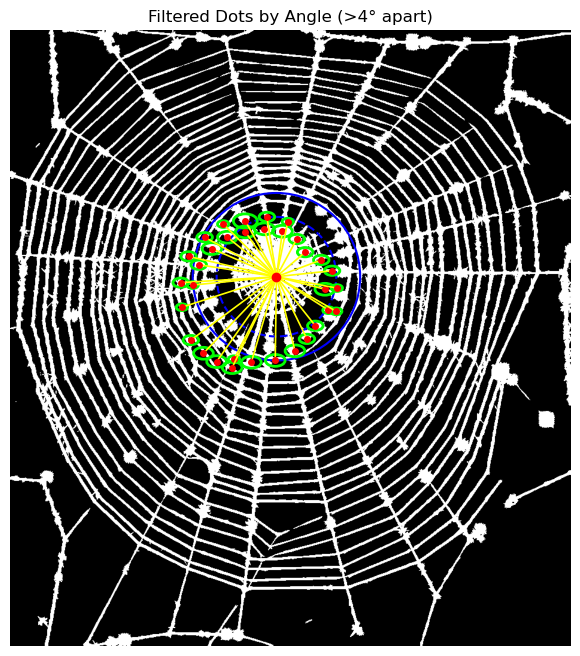

33 dots found


In [199]:
dots = detect_radial_dots_filtered(edited, center = refined_center)
print(str(len(dots)) + " dots found")

In [ ]:
import numpy as np

def filter_lines_by_angle(lines, center, angle_thresh_deg=5):
    """
    Filter radial lines by angular separation, keeping the longest line in each angle bin.

    Args:
        lines: list of ((x0, y0), (x1, y1)) line endpoints.
        center: (x, y) center point.
        angle_thresh_deg: minimum angular separation between lines to keep.

    Returns:
        filtered_lines: filtered list of lines.
    """
    x_c, y_c = center
    angle_thresh = angle_thresh_deg
    bins = {}

    for line in lines:
        (x0, y0), (x1, y1) = line
        dx = x1 - x_c
        dy = y1 - y_c
        angle = (np.degrees(np.arctan2(dy, dx)) + 360) % 360
        length = np.hypot(dx, dy)

        bin_id = int(angle // angle_thresh)

        # Keep the longest line in this angle bin
        if bin_id not in bins or length > bins[bin_id][2]:
            bins[bin_id] = (line, angle, length)

    filtered_lines = [entry[0] for entry in bins.values()]
    return filtered_lines


In [166]:
def filter_radial_lines_by_dot_along_line(image_bin, center, dots,
                                          extension_factor=1.5,
                                          dot_match_thresh=10,
                                          min_dot_radius=6,
                                          visualize=True):
    """
    Keep only radial lines that intersect any other sufficiently large dot along their extended path.

    Args:
        image_bin: 2D binary image.
        center: (x, y) center point.
        dots: list of (x, y, r) dot detections.
        extension_factor: how far to extend the line beyond the detected dot.
        dot_match_thresh: distance threshold to consider a match.
        min_dot_radius: minimum radius to consider a dot valid for matching.
        visualize: whether to plot the debug info.

    Returns:
        accepted_lines: list of ((x0, y0), (x1, y1)) line endpoints.
    """
    x_c, y_c = center
    accepted_lines = []

    # Filter dots by radius to get candidate match dots
    candidate_dots = np.array([(x, y) for (x, y, r) in dots if r >= min_dot_radius])

    all_sampled_points = []

    for (x1, y1, _) in dots:
        dx = x1 - x_c
        dy = y1 - y_c

        # Extended endpoint
        x2 = int(round(x_c + dx * extension_factor))
        y2 = int(round(y_c + dy * extension_factor))
        x2 = np.clip(x2, 0, image_bin.shape[1] - 1)
        y2 = np.clip(y2, 0, image_bin.shape[0] - 1)

        # Sample all points along extended line (from x1,y1 to x2,y2)
        rr, cc = sk_line(y1, x1, y2, x2)
        sampled_points = np.stack([cc, rr], axis=1)
        all_sampled_points.extend(sampled_points)

        # Check if any of these points are near a large enough dot
        found_match = False
        for px, py in sampled_points:
            dists = np.linalg.norm(candidate_dots - np.array([px, py]), axis=1)
            if np.any((dists < dot_match_thresh) & (dists > 2)):
                found_match = True
                break

        if found_match:
            accepted_lines.append(((x_c, y_c), (x2, y2)))

    if visualize:
        plt.figure(figsize=(8, 8))
        plt.imshow(image_bin, cmap='gray')
        ax = plt.gca()

        # Draw all input dots (red)
        for x, y, _ in dots:
            ax.plot(x, y, 'ro', markersize=3)

        # Draw all sampled points (blue)
        for px, py in all_sampled_points:
            ax.plot(px, py, 'bo', markersize=1, alpha=0.3)

        # Draw accepted lines (yellow)
        for (start, end) in accepted_lines:
            ax.plot([start[0], end[0]], [start[1], end[1]], color='yellow', linewidth=1.5)

        ax.plot(x_c, y_c, 'ro', markersize=5)
        plt.title(f"{len(accepted_lines)} Radial Lines With Large Dot Along Path")
        plt.axis('off')
        plt.show()

    return accepted_lines



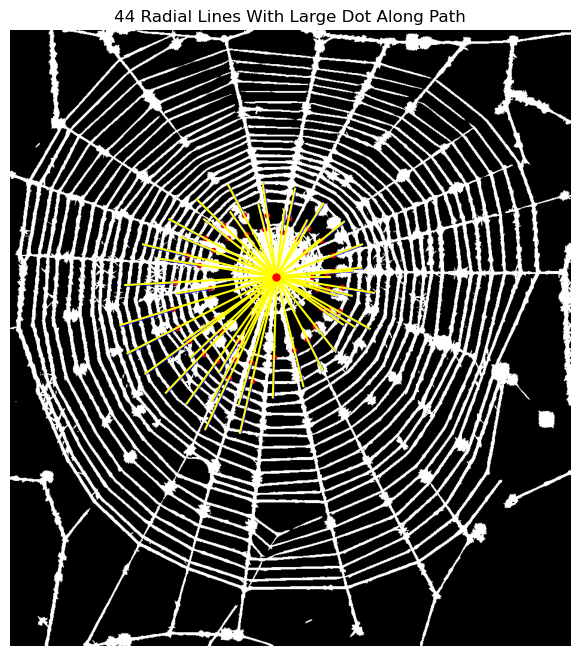

44


In [193]:
lines = filter_radial_lines_by_dot_along_line(edited, refined_center, dots)
print(len(lines))

In [222]:
import numpy as np
import matplotlib.pyplot as plt

def enforce_min_angle_gap(lines, center, image, min_angle_deg=7, visualize=True):
    """
    Filter lines to enforce a minimum angular gap between adjacent lines,
    including wrap-around between last and first line.
    Optionally visualize filtered lines overlaid on the image.

    Args:
        lines: list of ((x0, y0), (x1, y1)) line endpoints.
        center: (x, y) center point.
        image: image array (grayscale or color) for visualization background.
        min_angle_deg: minimum angular gap between lines.
        visualize: whether to display the filtered lines on the image.

    Returns:
        filtered_lines: list of filtered lines.
    """
    x_c, y_c = center

    # Compute angles of all lines
    lines_angles = []
    for line in lines:
        (x0, y0), (x1, y1) = line
        dx = x1 - x_c
        dy = y1 - y_c
        angle = (np.degrees(np.arctan2(dy, dx)) + 360) % 360
        lines_angles.append((line, angle))

    # Sort lines by angle
    lines_angles.sort(key=lambda x: x[1])

    filtered = []
    last_angle = None

    for line, angle in lines_angles:
        if last_angle is None:
            filtered.append(line)
            last_angle = angle
        else:
            diff = (angle - last_angle) % 360
            if diff >= min_angle_deg:
                filtered.append(line)
                last_angle = angle
            else:
                # Skip lines too close in angle
                pass

    # Check wrap-around gap between last and first filtered line
    if len(filtered) > 1:
        first_line = filtered[0]
        last_line = filtered[-1]

        first_angle = (np.degrees(np.arctan2(first_line[1][1] - y_c,
                                            first_line[1][0] - x_c)) + 360) % 360
        last_angle = (np.degrees(np.arctan2(last_line[1][1] - y_c,
                                           last_line[1][0] - x_c)) + 360) % 360

        wrap_gap = (first_angle - last_angle) % 360

        if wrap_gap < min_angle_deg:
            # Remove the shorter line of the two
            len_first = np.linalg.norm(np.subtract(first_line[1], first_line[0]))
            len_last = np.linalg.norm(np.subtract(last_line[1], last_line[0]))
            if len_first < len_last:
                filtered.pop(0)
            else:
                filtered.pop(-1)

    # Visualization
    if visualize:
        plt.figure(figsize=(8, 8))
        if image.ndim == 2:
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(image)
        ax = plt.gca()

        # Draw filtered lines in yellow
        for (start, end) in filtered:
            ax.plot([start[0], end[0]], [start[1], end[1]], color='yellow', linewidth=2)

        # Draw center point in red
        ax.plot(x_c, y_c, 'ro', markersize=6)

        plt.title(f"Filtered Lines with min angle gap {min_angle_deg}° (count: {len(filtered)})")
        plt.axis('off')
        plt.show()

    return filtered



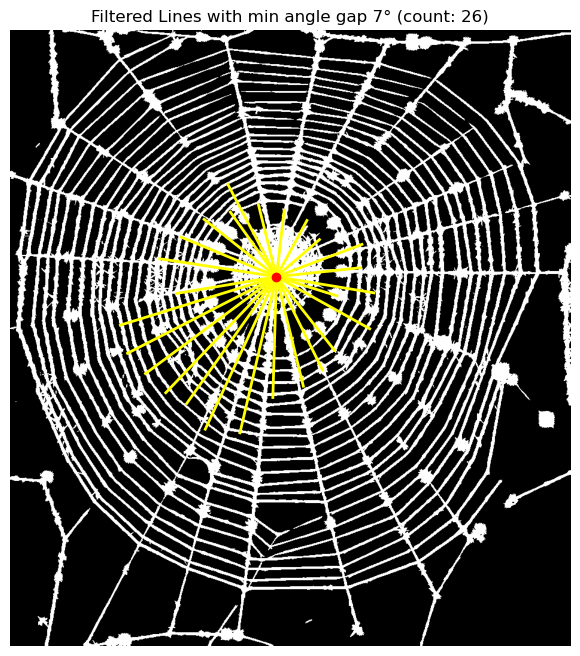

26


In [223]:
filtered_lines = enforce_min_angle_gap(image = edited, lines = lines, center = refined_center)
print(len(filtered_lines))

In [218]:
import numpy as np

def calculate_angles_between_lines(lines, center):
    """
    Calculate the sorted angles between adjacent radial lines,
    accounting for wrap-around between largest and smallest angle.

    Args:
        lines: list of ((x0, y0), (x1, y1)) line endpoints
        center: (x_c, y_c)

    Returns:
        angles_between: list of angles between adjacent lines in degrees
        stats: dict with min, max, mean, median of these angles
    """
    x_c, y_c = center
    angles = []

    # Compute angles of all lines
    for (x0, y0), (x1, y1) in lines:
        dx = x1 - x_c
        dy = y1 - y_c
        angle = (np.degrees(np.arctan2(dy, dx)) + 360) % 360
        angles.append(angle)

    angles = np.sort(angles)

    # Calculate differences between consecutive angles
    diffs = np.diff(angles)

    # Add the wrap-around difference between last and first angle
    wrap_diff = 360 - (angles[-1] - angles[0])
    angles_between = np.append(diffs, wrap_diff)

    stats = {
        "min": np.min(angles_between),
        "max": np.max(angles_between),
        "mean": np.mean(angles_between),
        "median": np.median(angles_between)
    }

    return angles_between.tolist(), stats


In [219]:
angles_between, stats = calculate_angles_between_lines(filtered_lines, center=refined_center)
print("Angles between adjacent lines:", angles_between)
print("Min gap:", stats["min"])
print("Max gap:", stats["max"])
print("Mean gap:", stats["mean"])
print("Median gap:", stats["median"])

Angles between adjacent lines: [8.174539925698411, 11.568220419057752, 22.591984252233885, 11.989469972642496, 12.455448588148954, 15.516379946587733, 11.453484866018243, 11.86205400675567, 10.264314319074344, 8.358462070572102, 9.869033448523794, 9.2855845780756, 9.964252706714205, 7.7235102379911496, 18.264111423503977, 13.796898737502687, 15.885016345626212, 16.084460256594866, 7.74425792571472, 13.70696100407983, 20.716129531148994, 21.80229968381792, 20.785707553250347, 20.04444812927437, 14.615202163227138, 15.477767908164594]
Min gap: 7.7235102379911496
Max gap: 22.591984252233885
Mean gap: 13.846153846153847
Median gap: 13.081204796114392
